# Data Quality – Outliers & Messy Data
**Course:** Data & Analytics | Prof. Dr. Sonja Schneider  
**Institution:** Technische Hochschule Nürnberg Georg Simon Ohm  

**Contributors:**
- Danny Schönhals
- Athithya Mariyanayagam

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
# Task 1: Autonomous Vehicle Survey of Bicyclists and Pedestrians in Pittsburgh

Load the survey data for **2017**.

In [48]:
# Load the 2017 survey data
df_av = pd.read_csv("data/av_survey_data/avsurvey2017data.csv", encoding="latin-1")
print(f"Shape: {df_av.shape}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_av.head()

cols = [
    'FeelingsProvingGround', 'SafetyHuman', 'SafetyAV',
    'AVSafetyPotential', 'PayingAttentionAV', 'FamiliarityTechnoology'
]
df_col = df_av[cols]
# Print missing values for each column
print("Missing values:")
for col in cols:
    missing_count = df_col[col].isna().sum()
    print(f"  {col}: {missing_count} ")

# See the unique values and range for each column
for col in cols:
    print(f"\n{col}")
    print(f"  dtype:  {df_col[col].dtype}")
    print(f"  range:  {df_col[col].min()} – {df_col[col].max()}")
    print(f"  values: {sorted(df_col[col].dropna().unique())}")

Shape: (1154, 22)
Missing values:
  FeelingsProvingGround: 34 
  SafetyHuman: 34 
  SafetyAV: 34 
  AVSafetyPotential: 34 
  PayingAttentionAV: 34 
  FamiliarityTechnoology: 34 

FeelingsProvingGround
  dtype:  str
  range:  Approve – Somewhat Disapprove
  values: ['Approve', 'Disapprove', 'Neutral', 'Somewhat Approve', 'Somewhat Disapprove']

SafetyHuman
  dtype:  str
  range:  1 – No experience
  values: ['1', '2', '3', '4', '5', 'No experience']

SafetyAV
  dtype:  str
  range:  1 – No experience
  values: ['1', '2', '3', '4', '5', 'No experience']

AVSafetyPotential
  dtype:  str
  range:  Maybe – Yes
  values: ['Maybe', 'No', 'Not sure', 'Yes']

PayingAttentionAV
  dtype:  str
  range:  Not at all – To some extent
  values: ['Not at all', 'To a large extent', 'To a moderate extent', 'To little extent', 'To some extent']

FamiliarityTechnoology
  dtype:  str
  range:  Extremely familiar – Somewhat familiar
  values: ['Extremely familiar', 'Mostly Unfamiliar', 'Mostly familiar', 'No

## 1a) Univariate Outlier Detection

Check for univariate outliers in the columns:
- `FeelingsProvingGround`
- `SafetyHuman`
- `SafetyAV`
- `AVSafetyPotential`
- `PayingAttentionAV`
- `FamiliarityTechnoology`

Select **sensible metrics and thresholds** for outlier detection and justify your choices.

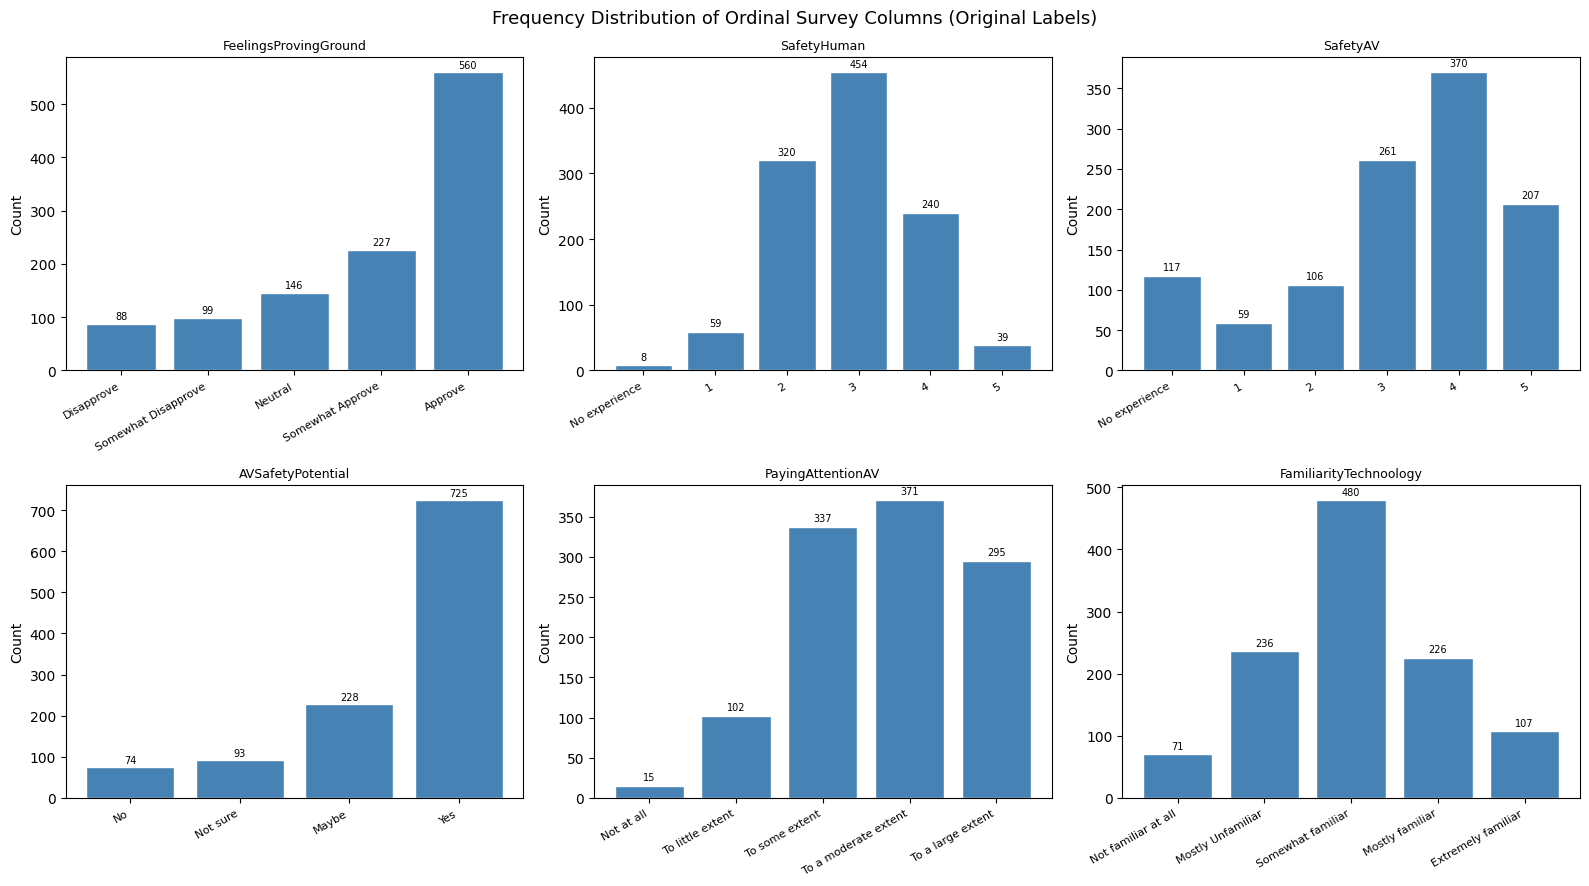

FeelingsProvingGround: 0 outliers (0.0%)
SafetyHuman: 47 outliers (4.2%)
SafetyAV: 0 outliers (0.0%)
AVSafetyPotential: 74 outliers (6.61%)
PayingAttentionAV: 0 outliers (0.0%)
FamiliarityTechnoology: 0 outliers (0.0%)


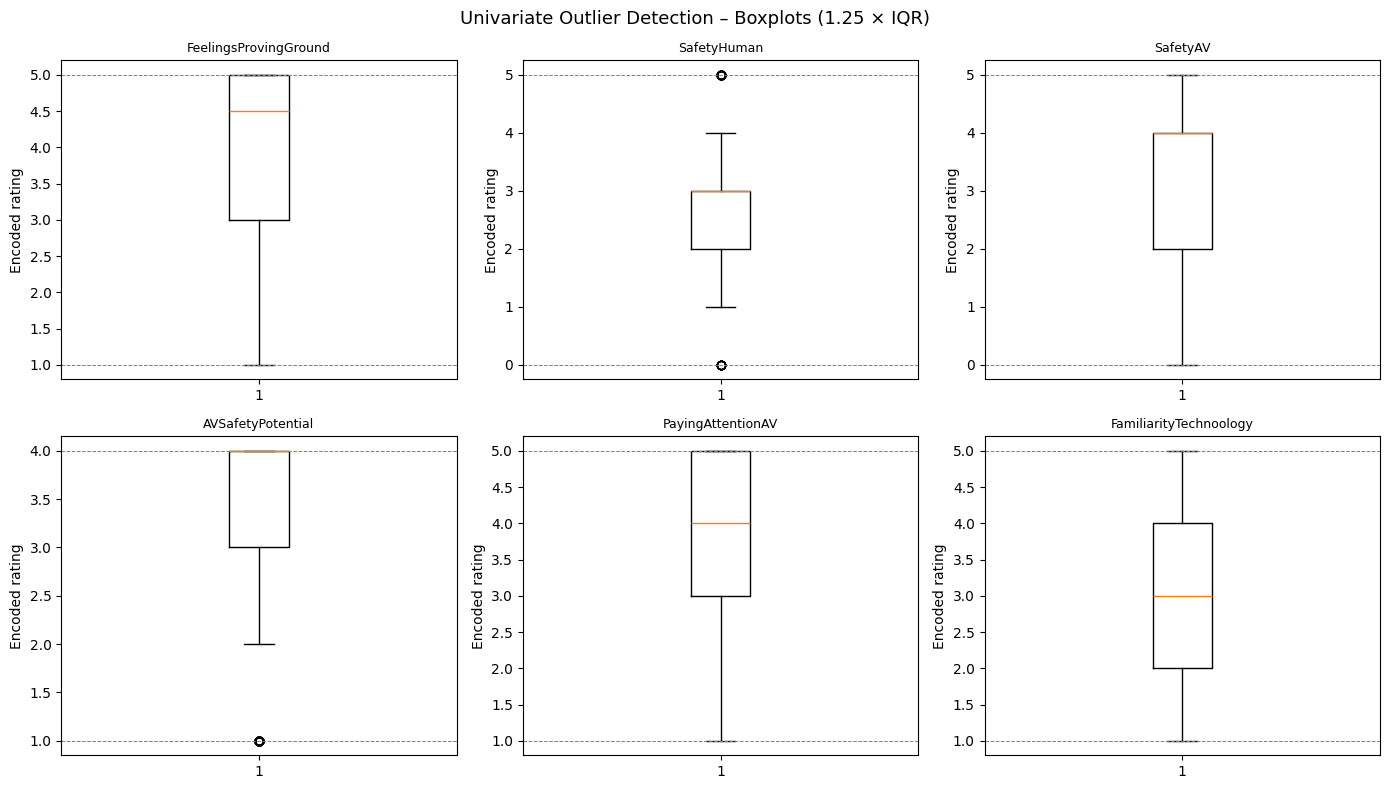

In [49]:
ordinal_maps = {
    'FeelingsProvingGround': {
        'Disapprove': 1, 'Somewhat Disapprove': 2, 'Neutral': 3,
        'Somewhat Approve': 4, 'Approve': 5
    },
    'SafetyHuman': {
        'No experience': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5
        
    },
    'SafetyAV': {
        'No experience': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5
        
    },
    'AVSafetyPotential': {
        'No': 1, 'Not sure': 2, 'Maybe': 3, 'Yes': 4
    },
    'PayingAttentionAV': {
        'Not at all': 1, 'To little extent': 2, 'To some extent': 3,
        'To a moderate extent': 4, 'To a large extent': 5
    },
    'FamiliarityTechnoology': {
        'Not familiar at all': 1, 'Mostly Unfamiliar': 2, 'Somewhat familiar': 3,
        'Mostly familiar': 4, 'Extremely familiar': 5
    }
}

# --- Frequency bar charts (original labels, ordinal order) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cols):
    ordered_cats = list(ordinal_maps[col].keys())
    counts = df_col[col].value_counts().reindex(ordered_cats, fill_value=0)
    bars = axes[i].bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=30, ha='right', fontsize=8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        if val > 0:
            axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                         str(val), ha='center', va='bottom', fontsize=7)

plt.suptitle('Frequency Distribution of Ordinal Survey Columns (Original Labels)', fontsize=13)
plt.tight_layout()
plt.show()

#--- Boxplots (encoded values, ordinal order) ---# Encode the ordinal columns using the defined mappings
df_enc = df_col[cols].copy()
for col, mapping in ordinal_maps.items():
    df_enc[col] = df_col[col].map(mapping)  # unmapped values → NaN automatically

df_enc.head()

results = []
threshold = 1.5  # IQR multiplier for outlier detection (stricter than the common 1.5)

for col in cols:
    data = df_enc[col].dropna()
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold * IQR
    upper = Q3 + threshold * IQR
    outliers = data[(data < lower) | (data > upper)]
    
    results.append({
        'Column':     col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower': lower, 'Upper': upper,
        'N outliers':  len(outliers),
        '% outliers':  round(len(outliers) / len(data) * 100, 2)
    })
    print(f"{col}: {len(outliers)} outliers ({round(len(outliers) / len(data) * 100, 2)}%)")

pd.DataFrame(results)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df_enc[col].dropna(), whis=threshold)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Encoded rating')
    # add reference lines for scale boundaries
    axes[i].axhline(df_enc[col].max(), color='grey', linestyle='--', linewidth=0.7)
    axes[i].axhline(df_enc[col].min(), color='grey', linestyle='--', linewidth=0.7)

plt.suptitle('Univariate Outlier Detection – Boxplots (1.25 × IQR)', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretation:**

- The frequency charts show all six columns follow expected ordinal distributions with no impossible values present, confirming the data is structurally clean.
- Applying IQR-based outlier detection (threshold = 1.5) to the encoded ordinal values flags "5" and "no experience" as outliers in `SafetyHuman` and "1" ("No") as an outlier in`AVSafetyPotencial`, since they sit well below Q1 of the remaining scale.
- By taking a look at the barplot of `SafetyHuman` that visualize the distribution, it gets clear that either "5" shouldn't be an outlier or 1 should also be an outlier (in addition to 0 and 5). Setting a fitting threshold to show this in the barplot was difficult without going under a threshold of 1.5.
- The flagged `"No experience"` responses are not errors but a meaningful subgroup; they should be kept but treated separately in further analysis.

## 1b) ZipCode Validation

Check the `ZipCode` column for **unrealistic or malformed values**. Investigate which zip codes appear most commonly and examine which others do not seem similar.

ZipCode
15217.0    122
15206.0    102
15212.0     70
15201.0     69
15224.0     62
15232.0     43
15221.0     43
15218.0     40
15222.0     37
15203.0     36
Name: count, dtype: int64
ZipCode
15030.0    1
15019.0    1
15033.0    1
15005.0    1
97206.0    1
15864.0    1
15062.0    1
16602.0    1
15142.0    1
15661.0    1
Name: count, dtype: int64


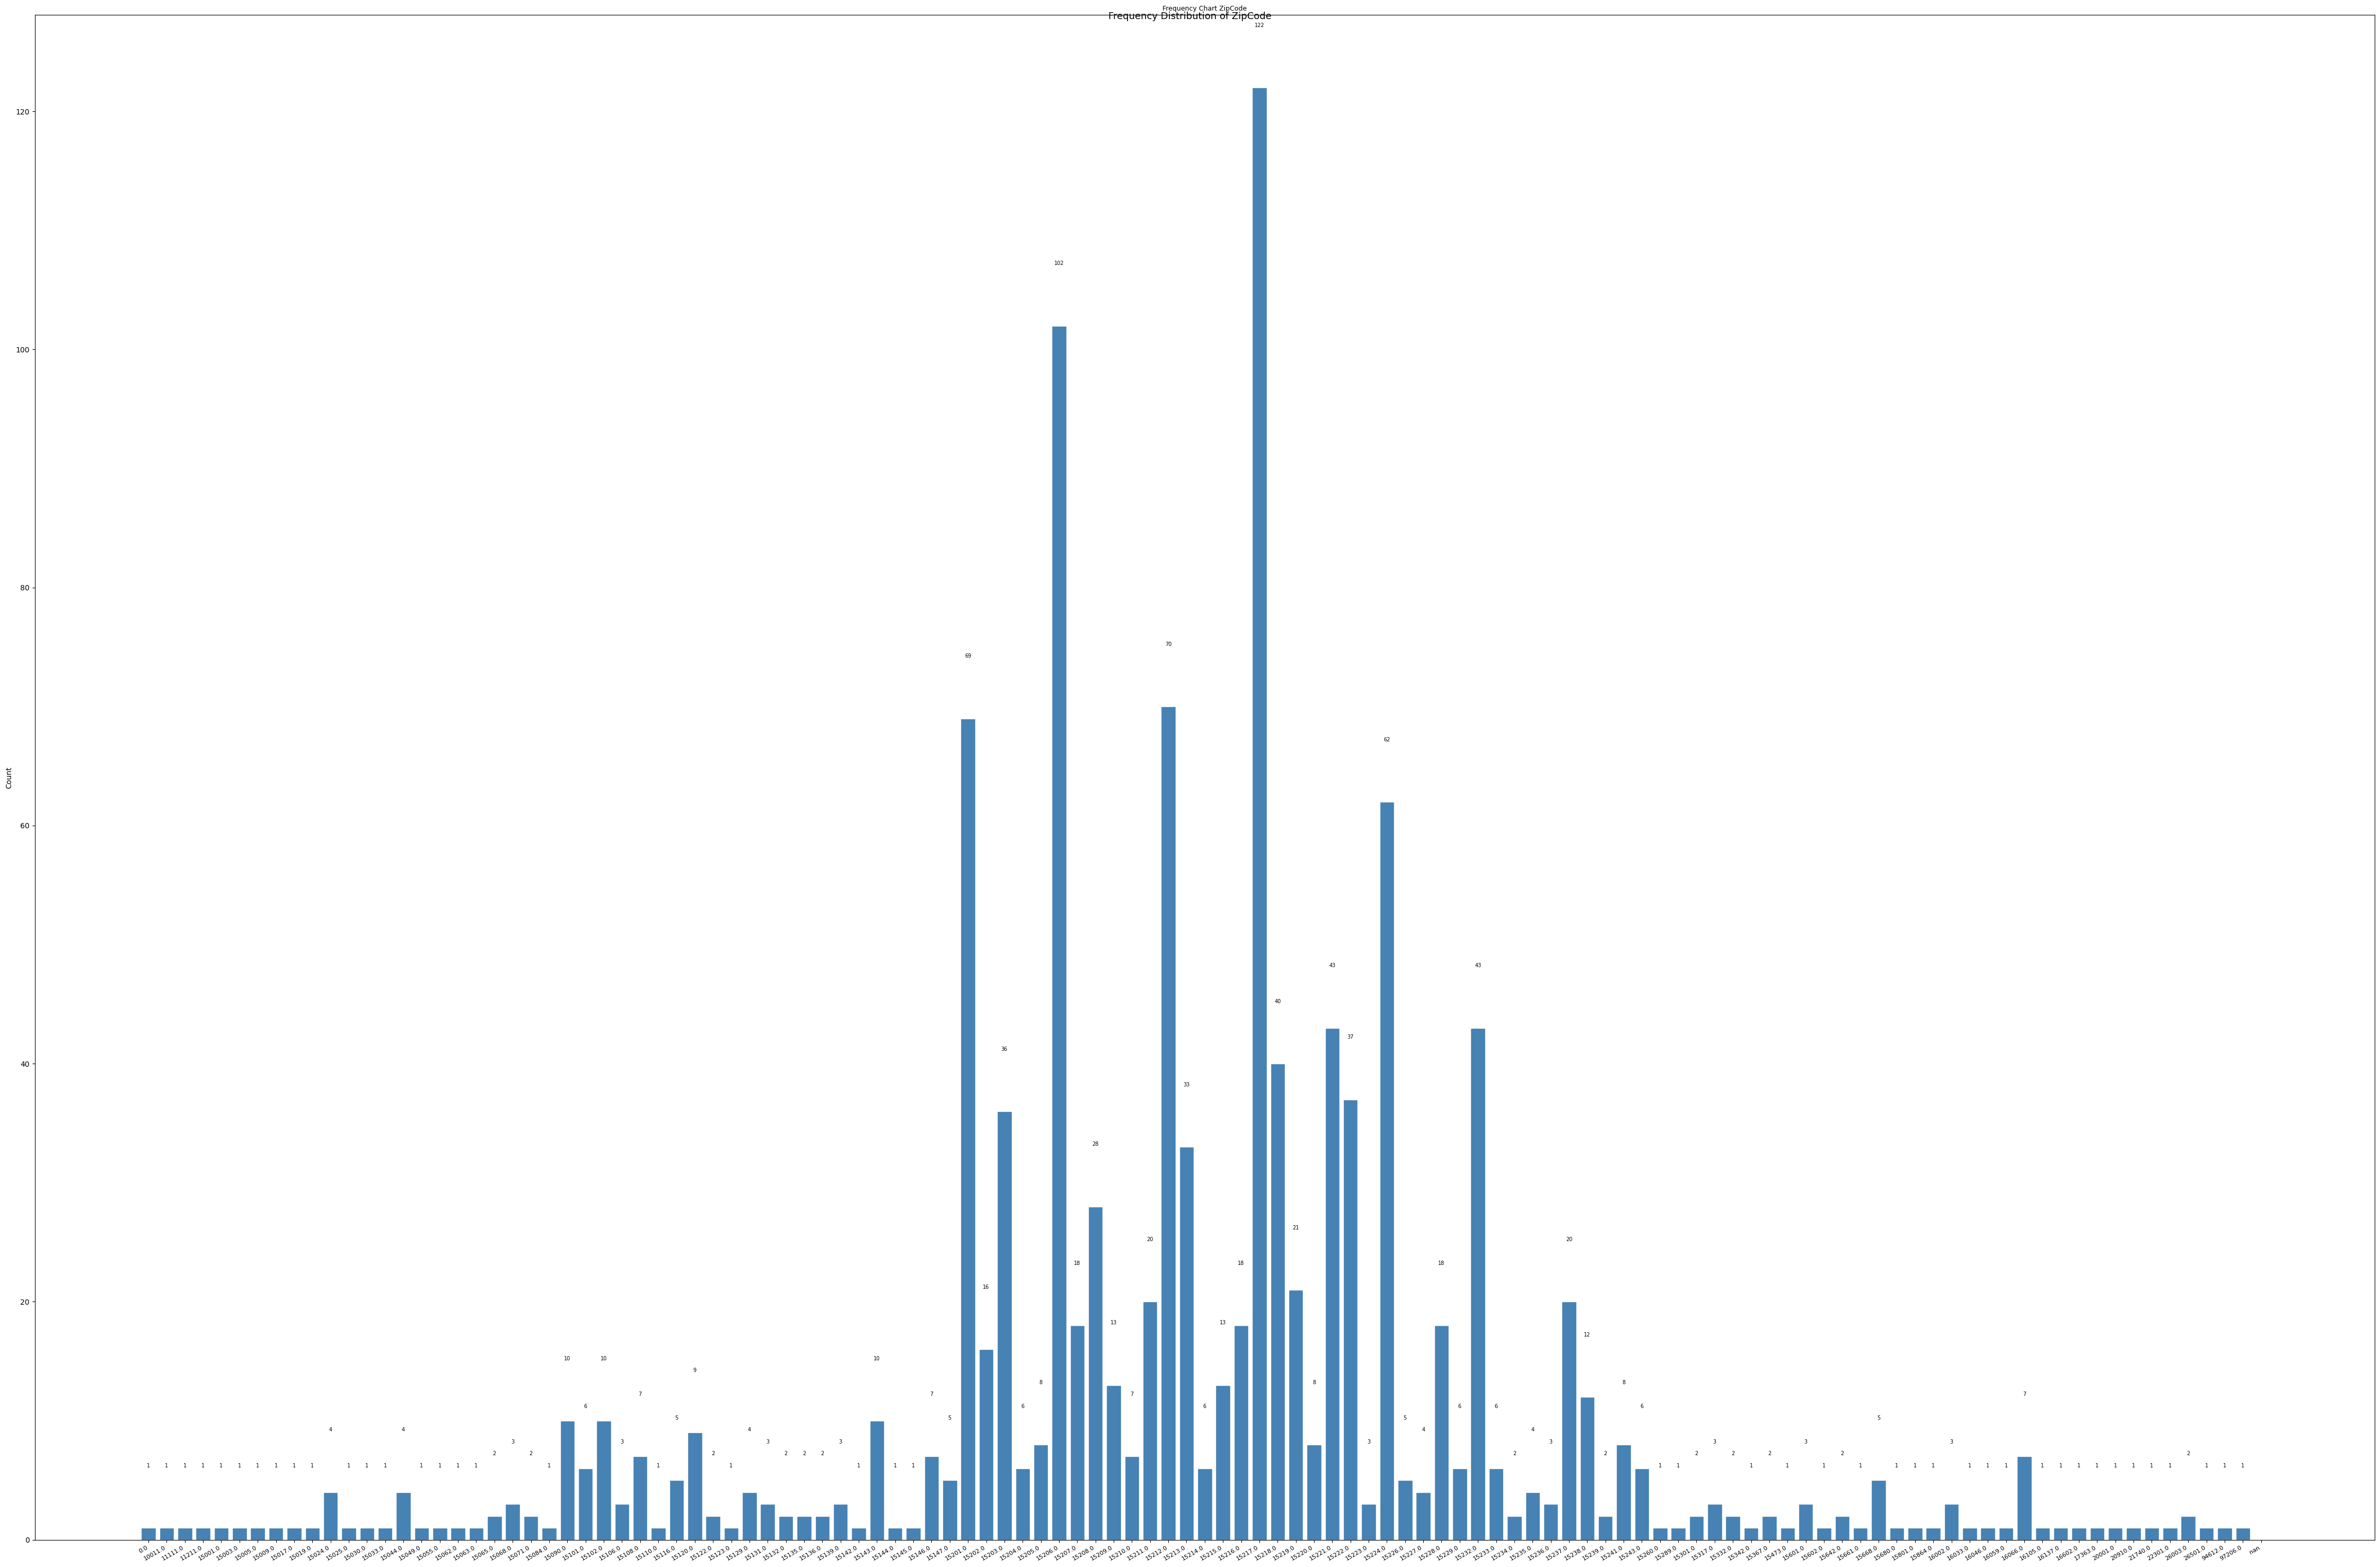

In [50]:
print(df_av["ZipCode"].value_counts().head(10))
print(df_av["ZipCode"].value_counts().tail(10))


# --- Frequency bar chart ---
fig, ax = plt.subplots(figsize=(45, 30))
ordered_zips = df_av["ZipCode"].sort_values().unique()
count_zips = df_av["ZipCode"].value_counts().reindex(ordered_zips, fill_value=0)
bars = ax.bar(range(len(count_zips)), count_zips.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(count_zips)))
ax.set_xticklabels(count_zips.index, rotation=30, ha='right', fontsize=8)
ax.set_title("Frequency Chart ZipCode", fontsize=9)
ax.set_ylabel('Count')
for bar, val in zip(bars, count_zips.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                        str(val), ha='center', va='bottom', fontsize=7)

plt.suptitle('Frequency Distribution of ZipCode', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretation:**

- The vast majority of respondents report Pittsburgh-area zip codes (152xx), which is expected given the study's local scope.
- A small number of zip codes fall entirely outside Pennsylvania or appear as freeform text entries (e.g. "N/A", short strings), representing structural data quality issues — violated format constraints per the lecture's messy-data taxonomy.
- These outlier zip codes likely reflect survey respondents who misunderstood the field or entered placeholder values, not legitimate geographic diversity.
- They should be treated as missing/invalid rather than informative values

## 1c) Rare Combinations of Variables

Check for **rare combinations** of the variables `SafetyAV` and:
- `CircumstancesCoded`
- `FeelingsProvingGround`

Take into account the **marginal probabilities** when assessing rarity. Discuss your findings.

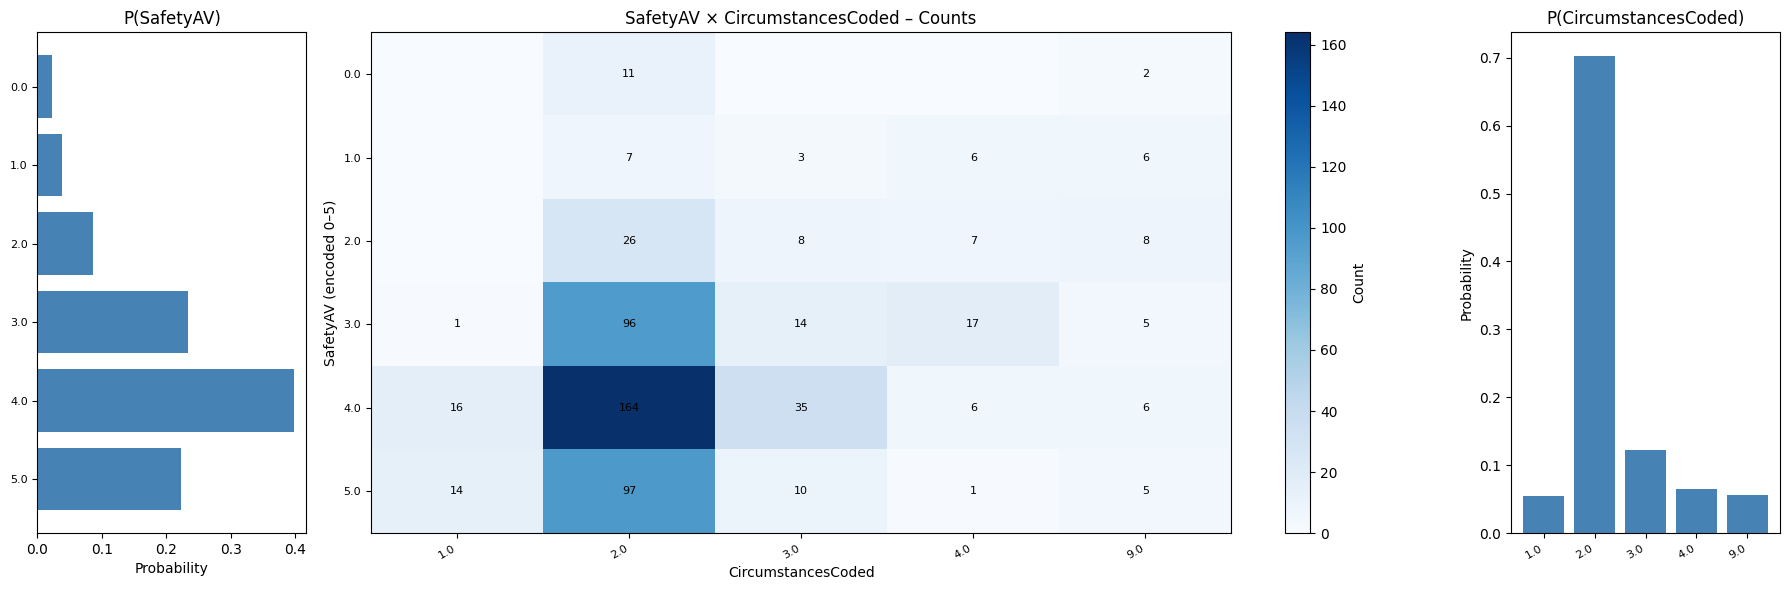

In [51]:
# Combo 1: SafetyAV × CircumstancesCoded
df_c1 = pd.DataFrame({
    'SafetyAV': df_enc['SafetyAV'],
    'CircumstancesCoded': df_av['CircumstancesCoded']
}).dropna()

counts1 = df_c1.groupby(['SafetyAV', 'CircumstancesCoded']).size().unstack(fill_value=0)
n1 = len(df_c1)
p_sav  = (df_c1['SafetyAV'].value_counts() / n1).reindex(counts1.index, fill_value=0)
p_circ = (df_c1['CircumstancesCoded'].value_counts() / n1).reindex(counts1.columns, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 4, 1]})

# Left: P(SafetyAV) – horizontal bars, top-down to match heatmap rows
axes[0].barh(range(len(p_sav)), p_sav.values, color='steelblue')
axes[0].set_yticks(range(len(p_sav)))
axes[0].set_yticklabels(p_sav.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Probability')
axes[0].set_title('P(SafetyAV)')

# Center: count heatmap
im = axes[1].imshow(counts1.values, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=axes[1], label='Count')
axes[1].set_xticks(range(len(counts1.columns)))
axes[1].set_xticklabels(counts1.columns, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(counts1.index)))
axes[1].set_yticklabels(counts1.index, fontsize=8)
axes[1].set_xlabel('CircumstancesCoded')
axes[1].set_ylabel('SafetyAV (encoded 0–5)')
axes[1].set_title('SafetyAV × CircumstancesCoded – Counts')
for i in range(len(counts1.index)):
    for j in range(len(counts1.columns)):
        val = counts1.values[i, j]
        if val > 0:
            axes[1].text(j, i, str(val), ha='center', va='center', fontsize=8)

# Right: P(CircumstancesCoded) – vertical bars, left-to-right to match heatmap columns
axes[2].bar(range(len(p_circ)), p_circ.values, color='steelblue')
axes[2].set_xticks(range(len(p_circ)))
axes[2].set_xticklabels(p_circ.index, rotation=30, ha='right', fontsize=8)
axes[2].set_ylabel('Probability')
axes[2].set_title('P(CircumstancesCoded)')

plt.tight_layout()
plt.show()

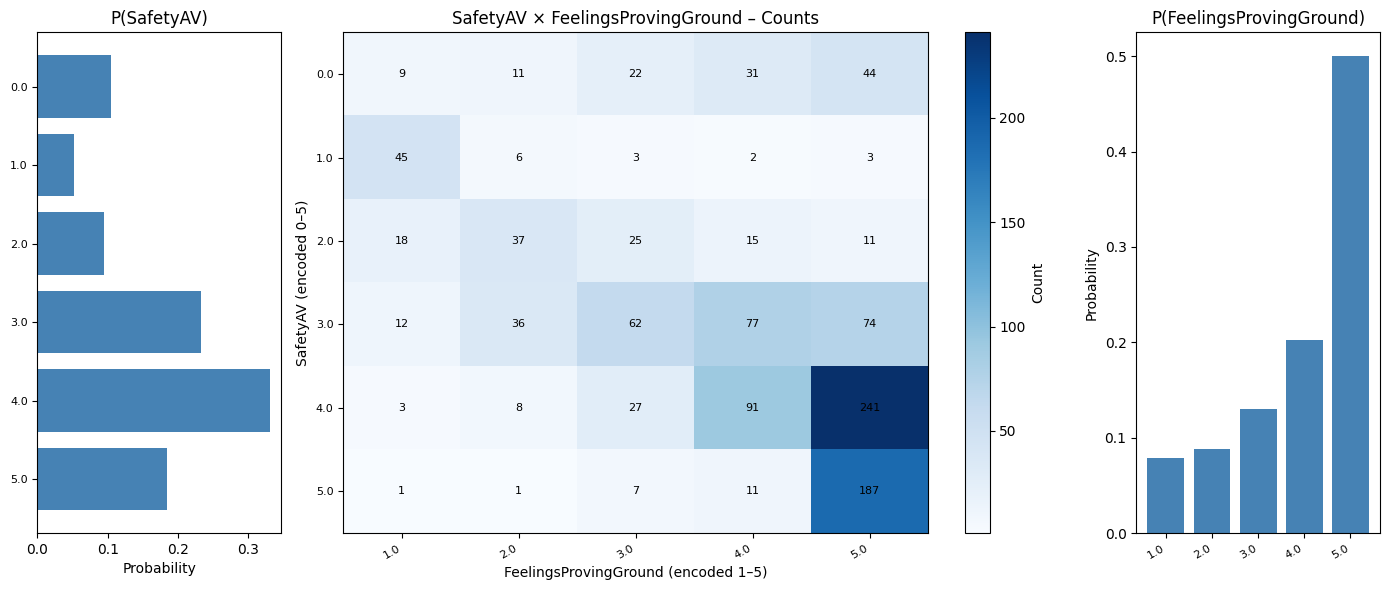

In [52]:
# Combo 2: SafetyAV × FeelingsProvingGround
df_c2 = df_enc[['SafetyAV', 'FeelingsProvingGround']].dropna()

counts2 = df_c2.groupby(['SafetyAV', 'FeelingsProvingGround']).size().unstack(fill_value=0)
n2 = len(df_c2)
p_sav2 = (df_c2['SafetyAV'].value_counts() / n2).reindex(counts2.index, fill_value=0)
p_feel = (df_c2['FeelingsProvingGround'].value_counts() / n2).reindex(counts2.columns, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 3, 1]})

# Left: P(SafetyAV) – horizontal bars, top-down to match heatmap rows
axes[0].barh(range(len(p_sav2)), p_sav2.values, color='steelblue')
axes[0].set_yticks(range(len(p_sav2)))
axes[0].set_yticklabels(p_sav2.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Probability')
axes[0].set_title('P(SafetyAV)')

# Center: count heatmap
im = axes[1].imshow(counts2.values, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=axes[1], label='Count')
axes[1].set_xticks(range(len(counts2.columns)))
axes[1].set_xticklabels(counts2.columns, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(counts2.index)))
axes[1].set_yticklabels(counts2.index, fontsize=8)
axes[1].set_xlabel('FeelingsProvingGround (encoded 1–5)')
axes[1].set_ylabel('SafetyAV (encoded 0–5)')
axes[1].set_title('SafetyAV × FeelingsProvingGround – Counts')
for i in range(len(counts2.index)):
    for j in range(len(counts2.columns)):
        val = counts2.values[i, j]
        if val > 0:
            axes[1].text(j, i, str(val), ha='center', va='center', fontsize=8)

# Right: P(FeelingsProvingGround) – vertical bars, left-to-right to match heatmap columns
axes[2].bar(range(len(p_feel)), p_feel.values, color='steelblue')
axes[2].set_xticks(range(len(p_feel)))
axes[2].set_xticklabels(p_feel.index, rotation=30, ha='right', fontsize=8)
axes[2].set_ylabel('Probability')
axes[2].set_title('P(FeelingsProvingGround)')

plt.tight_layout()
plt.show()

**Interpretation:**

- The marginal probability plots reveal that some combinations appear rare simply because one of the two variables is itself rarely chosen. This is expected under independence and not suspicious (Kennedy, 2024, Tables 2.3–2.5).
- Combinations worth flagging are those where both marginals are relatively common but the joint count is still very low, indicating the co-occurrence is suppressed beyond what chance alone would predict.
- For `SafetyAV × CircumstancesCoded`, certain circumstance categories appear almost exclusively at mid-range safety ratings, making combinations at the extremes (0 or 5) genuinely rare relative to their marginals.
- For `SafetyAV × FeelingsProvingGround`, the distribution is more balanced; most cells have counts consistent with their marginals, suggesting these two attitudes are largely independent in this sample.

---
# Task 2: Degradation Measurement of Robot Arm Position Accuracy

For each time series (i.e. each of the original `.csv` files), compute the **maximum deviation between target and actual velocity** for each individual joint.

In [53]:
# Load the combined dataset
df_robot = pd.read_csv("data/robot_position_accuracy/ur5_combined.csv")
print(f"Shape: {df_robot.shape}")

joints = [1, 2, 3, 4, 5, 6]
group_cols = ['cold_start', 'speed', 'payload_lb', 'trial_number']

# Compute max absolute velocity deviation per joint, per time series
records = []
for keys, grp in df_robot.groupby(group_cols):
    row = dict(zip(group_cols, keys))
    for j in joints:
        dev = (grp[f'robot_target_joint_velocities_j{j}'] -
               grp[f'robot_actual_joint_velocities_j{j}']).abs()
        row[f'max_dev_j{j}'] = dev.max()
    records.append(row)

df_max_dev = pd.DataFrame(records)
print(f"Number of time series: {len(df_max_dev)}")
df_max_dev.head(18)


Shape: (153658, 77)
Number of time series: 18


,cold_start,speed,payload_lb,trial_number,max_dev_j1,max_dev_j2,max_dev_j3,max_dev_j4,max_dev_j5,max_dev_j6
0,False,fullspeed,1.6,1,0.031808,0.025362,0.022511,0.038519,0.028115,0.000128
1,False,fullspeed,1.6,2,0.031675,0.023649,0.022379,0.039816,0.036336,0.000824
2,False,fullspeed,1.6,3,0.030111,0.052650,0.034633,0.038265,0.045772,0.001236
3,False,fullspeed,4.5,1,0.029050,0.027180,0.013595,0.041853,0.057162,0.001314
4,False,fullspeed,4.5,2,0.038100,0.023302,0.020841,0.031149,0.046259,0.000264
5,False,fullspeed,4.5,3,0.029763,0.057696,0.020076,0.041933,0.049746,0.000887
6,False,halfspeed,1.6,1,0.014085,0.013445,0.009917,0.024370,0.050287,0.000000
7,False,halfspeed,1.6,2,0.016616,0.012499,0.009354,0.027390,0.049492,0.000000
8,False,halfspeed,1.6,3,0.010573,0.014036,0.008262,0.033400,0.056411,0.000526
9,False,halfspeed,4.5,1,0.018981,0.038246,0.025311,0.064331,0.048863,0.000000


## 2a) Distribution of Velocity Deviations per Joint

Visualize the distribution of maximum velocity deviations for each joint using both **boxplots** and **histograms**. Discuss your conclusions regarding the existence of outliers.

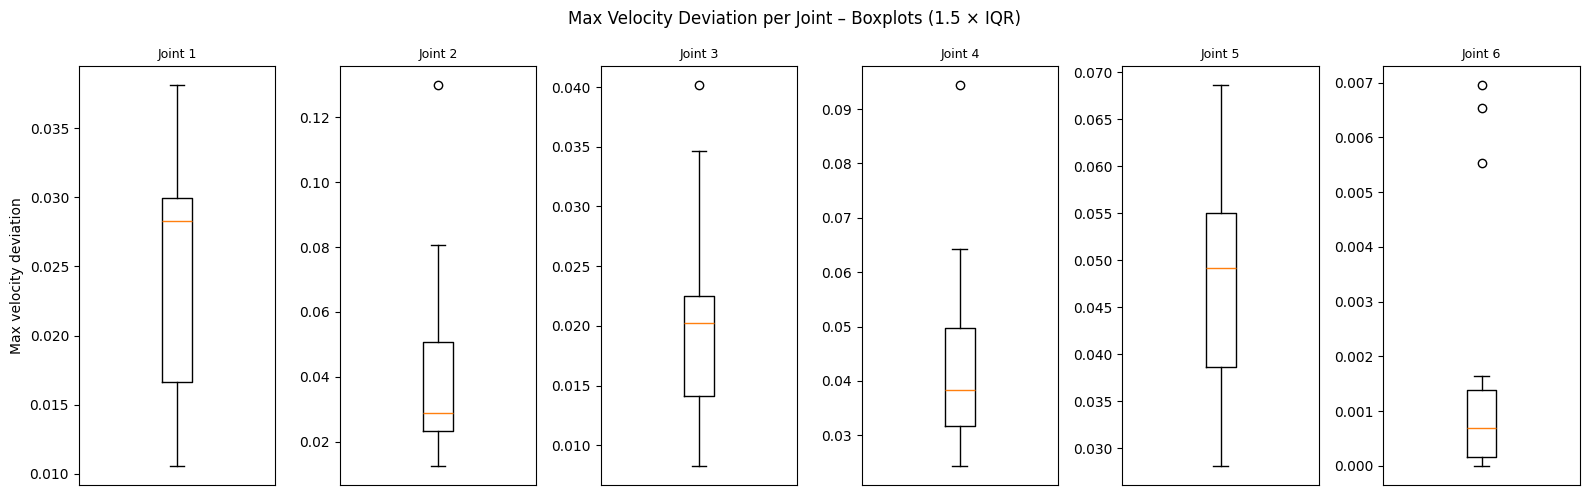

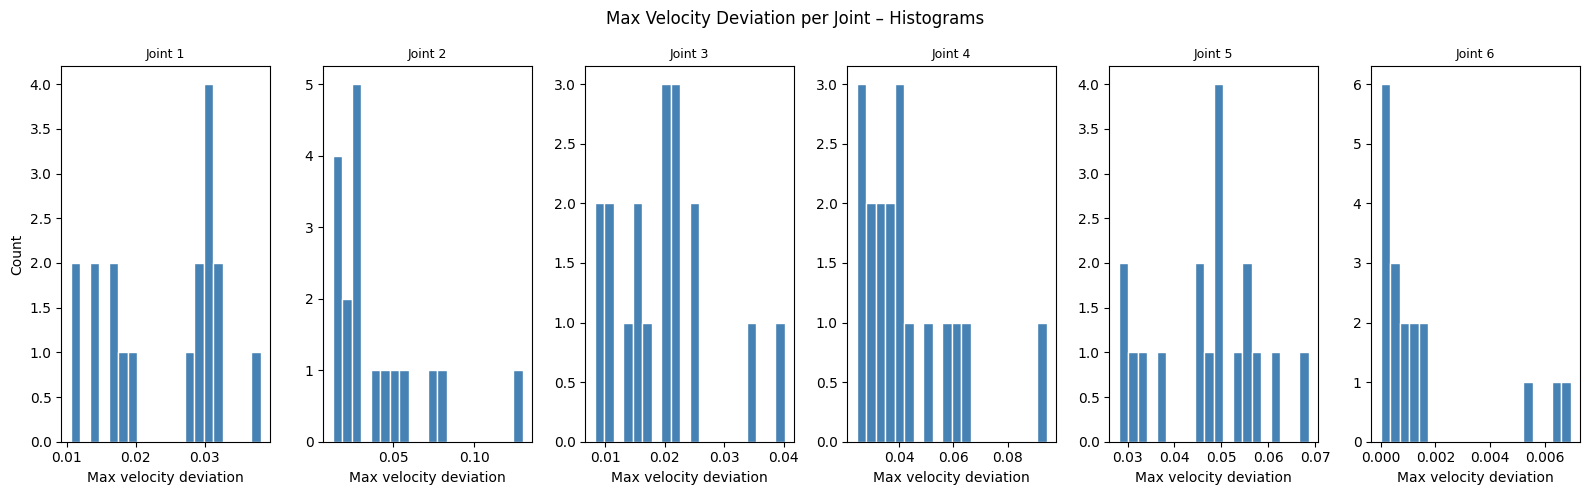

Specific Outliers Detected:

--- max_dev_j2 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j2
      False halfspeed         4.5             2    0.129839

--- max_dev_j3 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j3
      False halfspeed         4.5             2     0.04014

--- max_dev_j4 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j4
      False halfspeed         4.5             2    0.094365

--- max_dev_j6 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j6
       True fullspeed         4.5             2    0.005537
       True fullspeed         4.5             3    0.006533
       True halfspeed         4.5             1    0.006951


In [54]:
dev_cols = [f'max_dev_j{j}' for j in joints]

# --- Boxplots ---
fig, axes = plt.subplots(1, 6, figsize=(16, 5))
for i, col in enumerate(dev_cols):
    axes[i].boxplot(df_max_dev[col].dropna(), whis=1.5)
    axes[i].set_title(f'Joint {i+1}', fontsize=9)
    axes[i].set_ylabel('Max velocity deviation' if i == 0 else '')
    axes[i].set_xticks([])

plt.suptitle('Max Velocity Deviation per Joint – Boxplots (1.5 × IQR)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Histograms ---
fig, axes = plt.subplots(1, 6, figsize=(16, 5))
for i, col in enumerate(dev_cols):
    axes[i].hist(df_max_dev[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Joint {i+1}', fontsize=9)
    axes[i].set_xlabel('Max velocity deviation')
    axes[i].set_ylabel('Count' if i == 0 else '')

plt.suptitle('Max Velocity Deviation per Joint – Histograms', fontsize=12)
plt.tight_layout()
plt.show()

print("Specific Outliers Detected:")
for col in dev_cols:
    data = df_max_dev[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    mask = (df_max_dev[col] < Q1 - 1.5 * IQR) | (df_max_dev[col] > Q3 + 1.5 * IQR)
    outliers = df_max_dev.loc[mask, group_cols + [col]]
    if len(outliers) > 0:
        print(f"\n--- {col} ---")
        print(outliers.to_string(index=False))

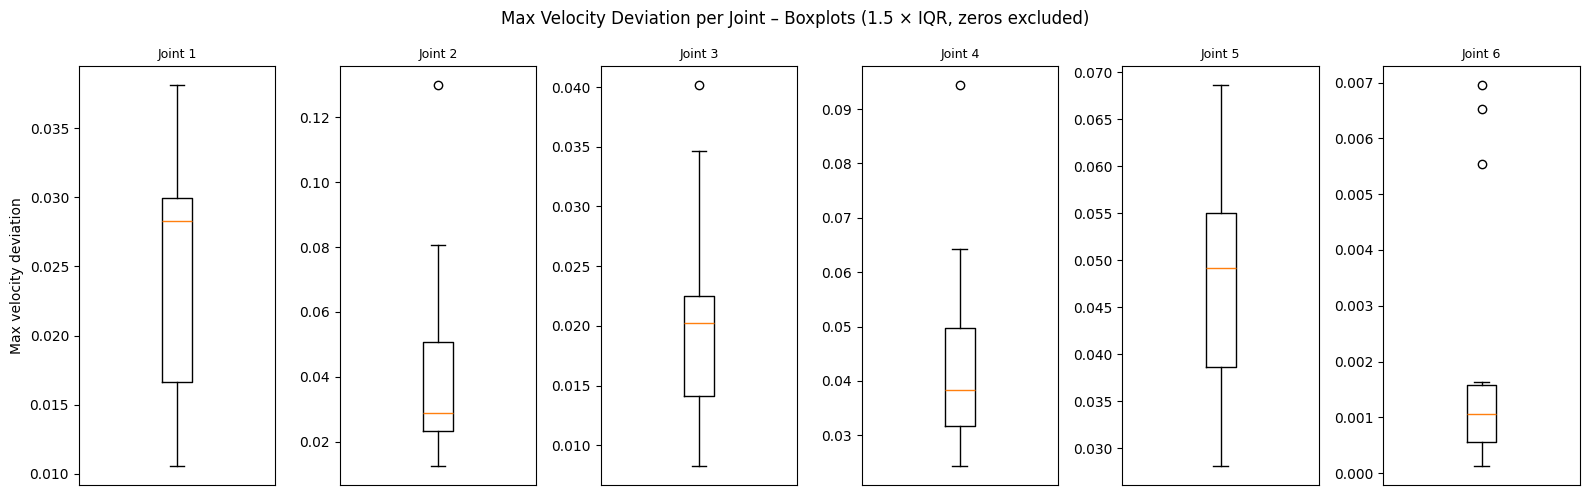

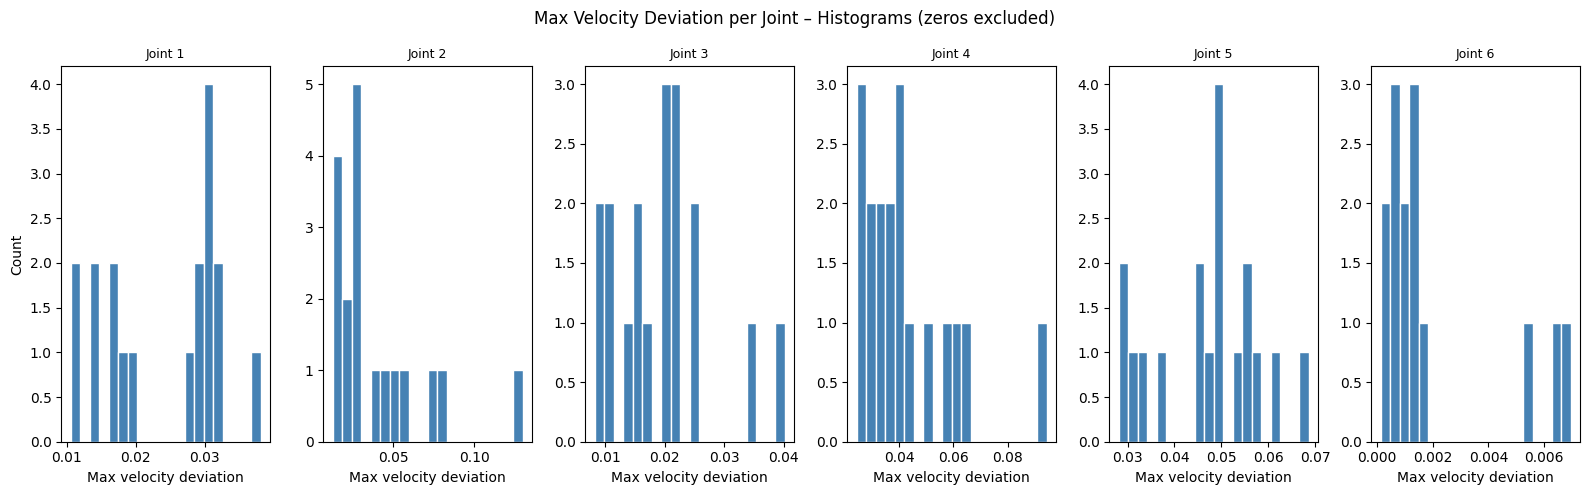

Specific Outliers Detected (zeros excluded):

--- max_dev_j2 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j2
      False halfspeed         4.5             2    0.129839

--- max_dev_j3 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j3
      False halfspeed         4.5             2     0.04014

--- max_dev_j4 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j4
      False halfspeed         4.5             2    0.094365

--- max_dev_j6 ---
 cold_start     speed  payload_lb  trial_number  max_dev_j6
       True fullspeed         4.5             2    0.005537
       True fullspeed         4.5             3    0.006533
       True halfspeed         4.5             1    0.006951


In [55]:
# --- Boxplots (zeros excluded per joint) ---
fig, axes = plt.subplots(1, 6, figsize=(16, 5))
for i, col in enumerate(dev_cols):
    data = df_max_dev[col].replace(0, np.nan).dropna()
    axes[i].boxplot(data, whis=1.5)
    axes[i].set_title(f'Joint {i+1}', fontsize=9)
    axes[i].set_ylabel('Max velocity deviation' if i == 0 else '')
    axes[i].set_xticks([])

plt.suptitle('Max Velocity Deviation per Joint – Boxplots (1.5 × IQR, zeros excluded)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Histograms (zeros excluded per joint) ---
fig, axes = plt.subplots(1, 6, figsize=(16, 5))
for i, col in enumerate(dev_cols):
    data = df_max_dev[col].replace(0, np.nan).dropna()
    axes[i].hist(data, bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Joint {i+1}', fontsize=9)
    axes[i].set_xlabel('Max velocity deviation')
    axes[i].set_ylabel('Count' if i == 0 else '')

plt.suptitle('Max Velocity Deviation per Joint – Histograms (zeros excluded)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Outliers (zeros excluded per joint) ---
print("Specific Outliers Detected (zeros excluded):")
for col in dev_cols:
    data = df_max_dev[col].replace(0, np.nan).dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    non_zero = df_max_dev[col].replace(0, np.nan)
    mask = (non_zero.notna()) & ((non_zero < Q1 - 1.5 * IQR) | (non_zero > Q3 + 1.5 * IQR))
    outliers = df_max_dev.loc[mask, group_cols + [col]]
    if len(outliers) > 0:
        print(f"\n--- {col} ---")
        print(outliers.to_string(index=False))


**Interpretation:**

- The boxplots and histograms reveal that most joints (j2–j3) have a right-skewed distribution of maximum velocity deviations, with a small number of trials producing unusually large deviations flagged as outliers via the 1.5 × IQR rule 
- Joints 1 and 6 stand out by showing a bimodal pattern. The histogramm for joint 6 also shows an odd value that could be seen as an internal outlier (between 0.005 and 0.006)
- Interesting in joint 6 is a cluster of trials with exactly 0.0 deviation and the rest following the bimodal distribution. The zero values are themselves outliers but not flagged because they lie near to the expected values. They indicate either a sensor failure (actual velocity not recorded) or a trial condition in which joint 6 was never commanded to move. Both cases make these time series non-comparable to the rest (Kennedy, 2024: inaccurate or structurally different observations).
- Excluding the zeros from joint 6 did not change which trials were flagged on the upper end, confirming the high-deviation outliers are genuinely extreme and not an artifact of the zero cluster pulling the IQR downward.
- Overall, the detected outliers should be investigated per their experimental condition (`cold_start`, `speed`, `payload_lb`, `trial_number`) before deciding whether to remove or keep them, as they may reflect real degradation or measurement error rather than random noise (Kennedy, 2024: distinguish *inaccurate* from *interesting* outliers).

## 2b) Internal Outlier Trial for Joint 6

Identify the trial that could be considered an **internal outlier** for velocity deviation in **joint 6**. Plot the original time series for all 3 trials that belong to the same experimental condition.

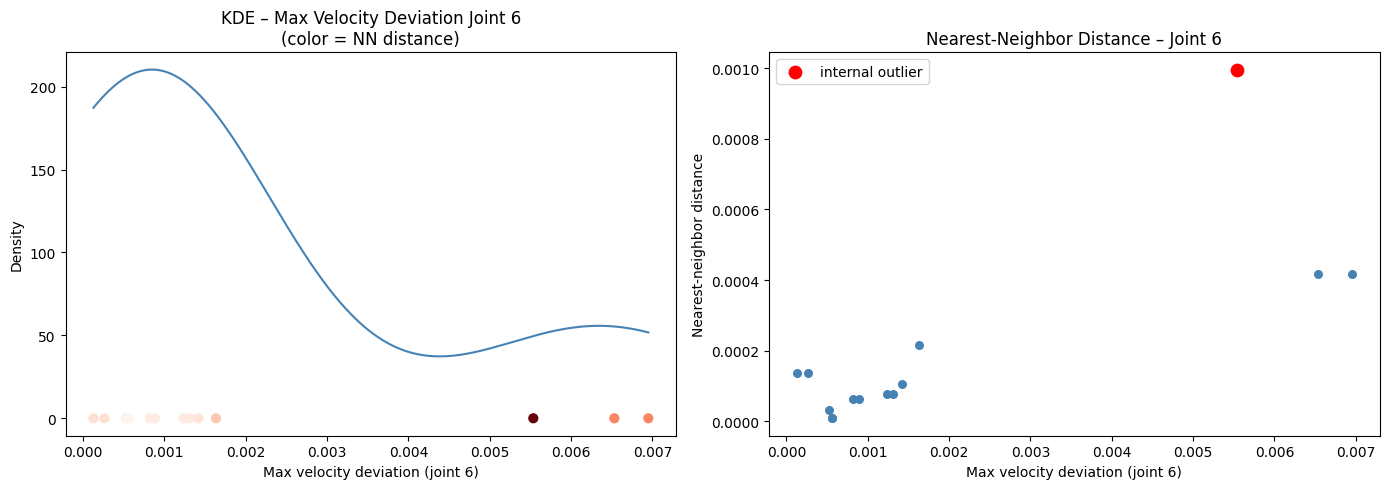

Internal outlier trial:
cold_start           True
speed           fullspeed
payload_lb            4.5
trial_number            2
max_dev_j6       0.005537
nn_dist          0.000996
Name: 10, dtype: object


In [ ]:
from scipy.stats import gaussian_kde
from sklearn.neighbors import NearestNeighbors

# Work on non-zero j6 values only
j6 = df_max_dev[df_max_dev['max_dev_j6'] > 0].copy().reset_index(drop=True)
vals = j6['max_dev_j6'].values.reshape(-1, 1)

# --- KDE ---
kde = gaussian_kde(vals.flatten(), bw_method='scott')
x_grid = np.linspace(vals.min(), vals.max(), 500)

# --- Nearest-neighbor distance (1D) ---
nn = NearestNeighbors(n_neighbors=2)
nn.fit(vals)
distances, _ = nn.kneighbors(vals)
j6['nn_dist'] = distances[:, 1]  # distance to nearest neighbor (col 0 = self)

# --- Plot KDE with NN distances ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_grid, kde(x_grid), color='steelblue')
axes[0].scatter(vals.flatten(), np.zeros_like(vals.flatten()),
                c=j6['nn_dist'], cmap='Reds', zorder=5, s=40, label='time series')
axes[0].set_xlabel('Max velocity deviation (joint 6)')
axes[0].set_ylabel('Density')
axes[0].set_title('KDE – Max Velocity Deviation Joint 6\n(color = NN distance)')
# save the index label of the row with the largest NN distance -> Outlier
outlier_idx = j6['nn_dist'].idxmax() 
axes[1].scatter(j6['max_dev_j6'], j6['nn_dist'], color='steelblue', s=30)
axes[1].scatter(j6.loc[outlier_idx, 'max_dev_j6'], j6.loc[outlier_idx, 'nn_dist'],
                color='red', zorder=5, s=80, label='internal outlier')
axes[1].set_xlabel('Max velocity deviation (joint 6)')
axes[1].set_ylabel('Nearest-neighbor distance')
axes[1].set_title('Nearest-Neighbor Distance – Joint 6')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Identify internal outlier ---
outlier_row = j6.loc[outlier_idx]
print("Internal outlier trial:")
print(outlier_row[group_cols + ['max_dev_j6', 'nn_dist']])


**Interpretation:**
- Using the gaussian KDE doesn't show the internal outlier that precise. But taking a closer look, shows that the estimated probability density is the lowest next to the expected internal outlier in task 2a
- Using the nearest neighbor calculation and visualizing it, shows a much better result. Looking at the distances computed for each point to its nearest neighbor (n_neighbors=2) shows that it is in fact an internal outlier. Compared to the distance of maximum 0.0004, max_dev_j6 for the time series "cold_start_fullspeed_4.5_2" has a distance of 0.001 to its nearest neighbor.

## 2c) Extreme Values in the 3 Time Series

Identify **potentially extreme values** for each of the 3 time series belonging to the experimental condition identified in 2b). Explain how you would handle them in further analysis.

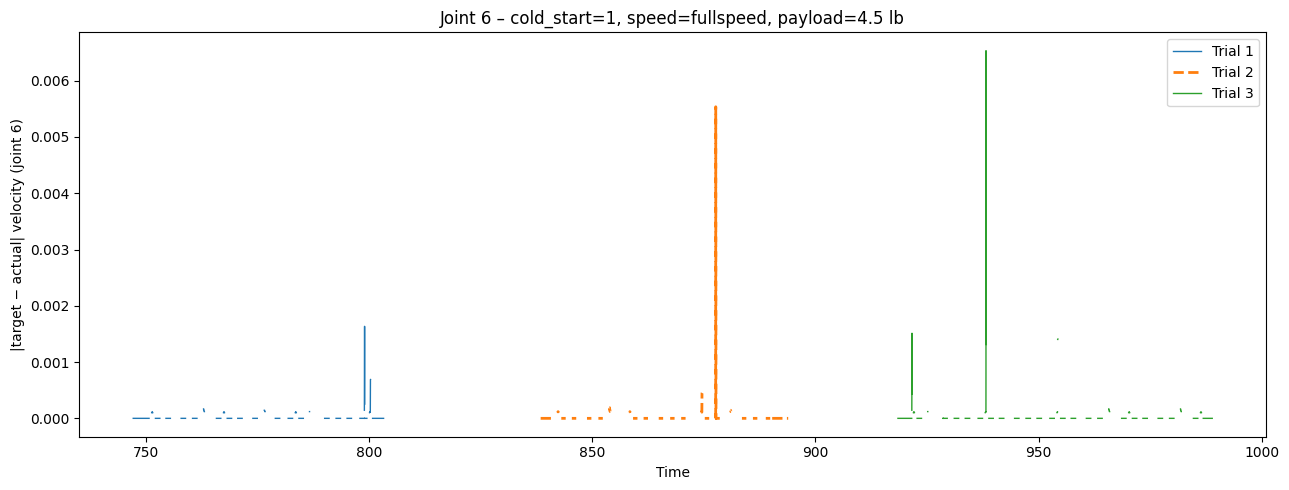

In [57]:
# --- Plot original time series for all 3 trials in same condition ---
cond_cols = ['cold_start', 'speed', 'payload_lb']
cond = outlier_row[cond_cols]

mask = ((df_robot['cold_start'] == cond['cold_start']) &
        (df_robot['speed']       == cond['speed'])      &
        (df_robot['payload_lb']  == cond['payload_lb']))
df_cond = df_robot[mask]

fig, ax = plt.subplots(figsize=(13, 5))
for trial, grp in df_cond.groupby('trial_number'):
    dev = (grp['robot_target_joint_velocities_j6'] -
           grp['robot_actual_joint_velocities_j6']).abs()
    lw = 2 if trial == outlier_row['trial_number'] else 1
    ls = '--' if trial == outlier_row['trial_number'] else '-'
    ax.plot(grp['robot_time'].values, dev.values,
            label=f'Trial {int(trial)}', linewidth=lw, linestyle=ls)

ax.set_xlabel('Time')
ax.set_ylabel('|target − actual| velocity (joint 6)')
ax.set_title(f'Joint 6 – cold_start={int(cond["cold_start"])}, '
             f'speed={cond["speed"]}, payload={cond["payload_lb"]} lb')
ax.legend()
plt.tight_layout()
plt.show()

Interpretation & Handling Strategy:

- All three trials show near-zero deviation for most of their duration, with isolated single-timestep spikes — these narrow peaks suggest momentary tracking errors rather than sustained mechanical issues, and are plausible for a robot arm at full speed with payload.
- Trial 3 has the highest spike (~0.0065), Trial 2 follows (~0.0055, the internal outlier), Trial 1 stays much lower (~0.0017) — the increasing pattern across trials is consistent with progressive degradation or thermal effects under cold_start=1, fullspeed, 4.5 lb.
- The extreme spikes are not clearly invalid — they could reflect genuine velocity overshoots during direction reversals at full speed. Without domain knowledge, flagging rather than removing is the appropriate first step.
- Handling: Since spikes are isolated single timesteps, replacing values above e.g. the 99th percentile with the percentile value itself  is the safest option. It dampens the extremes without discarding any trial or timestep, preserving the degradation signal for further analysis.
- If the spikes are later confirmed as sensor glitches (e.g. always occurring at the same relative position in the motion cycle), they can be removed or interpolated from their neighbors.
